## Task 4: Insights and Recommendations

In this section, we convert sentiment and thematic analysis results into business insights.

We aim to:
- Identify key satisfaction drivers and pain points per bank
- Compare banks across sentiment, ratings, and themes
- Provide actionable product and service recommendations
- Visualize key patterns using clear charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/sentiment_reviews.csv")
df.head()

,review,rating,date,bank,source,sentiment
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,positive
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,neutral
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play,negative
3,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,neutral
4,good apps,4,2026-05-16,Commercial Bank of Ethiopia,Google Play,positive


## Sentiment Distribution by Bank

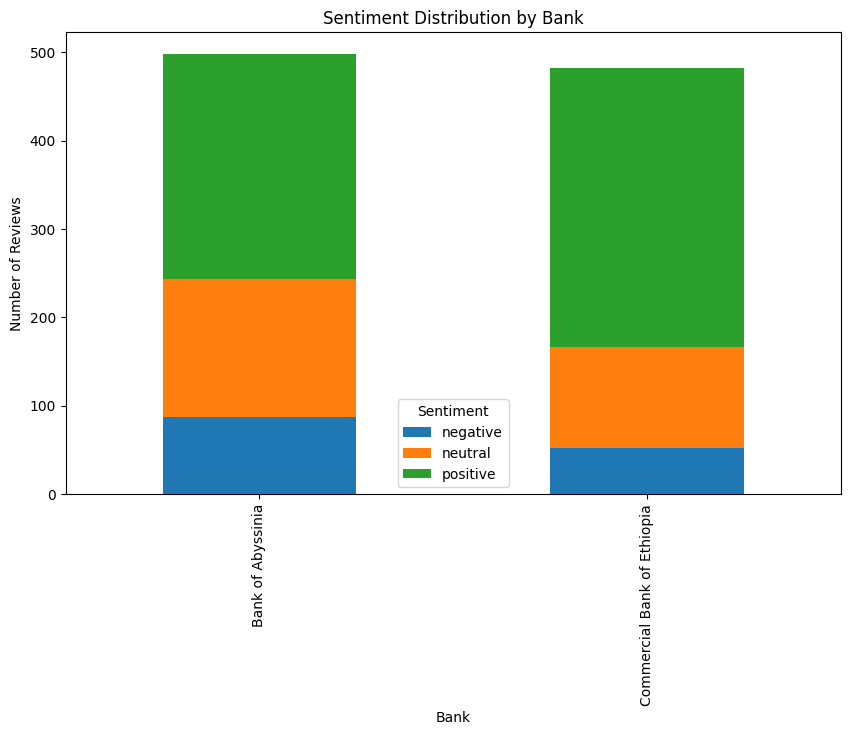

In [4]:
sentiment_counts = df.groupby(["bank", "sentiment"]).size().unstack()

sentiment_counts.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment")
plt.show()

## Rating Distribution

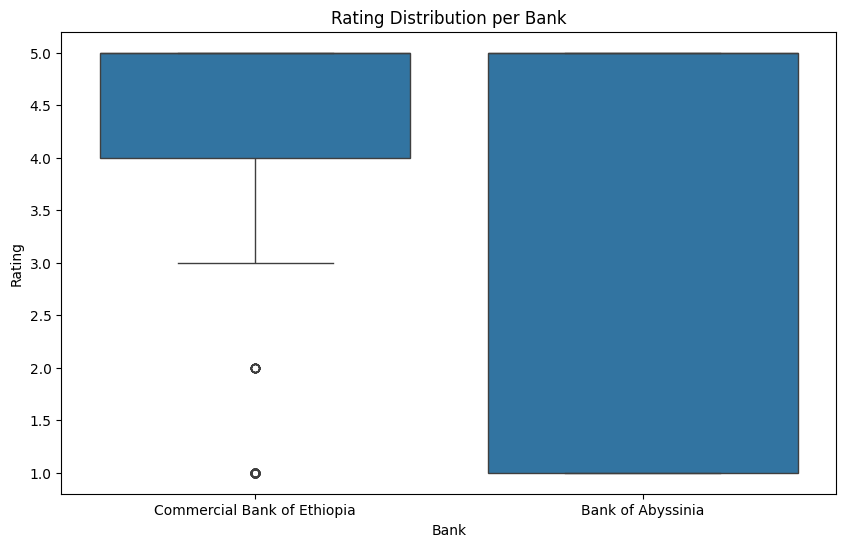

In [5]:
plt.figure(figsize=(10,6))

sns.boxplot(x="bank", y="rating", data=df)

plt.title("Rating Distribution per Bank")
plt.xlabel("Bank")
plt.ylabel("Rating")

plt.show()

## Theme Frequency per Bank

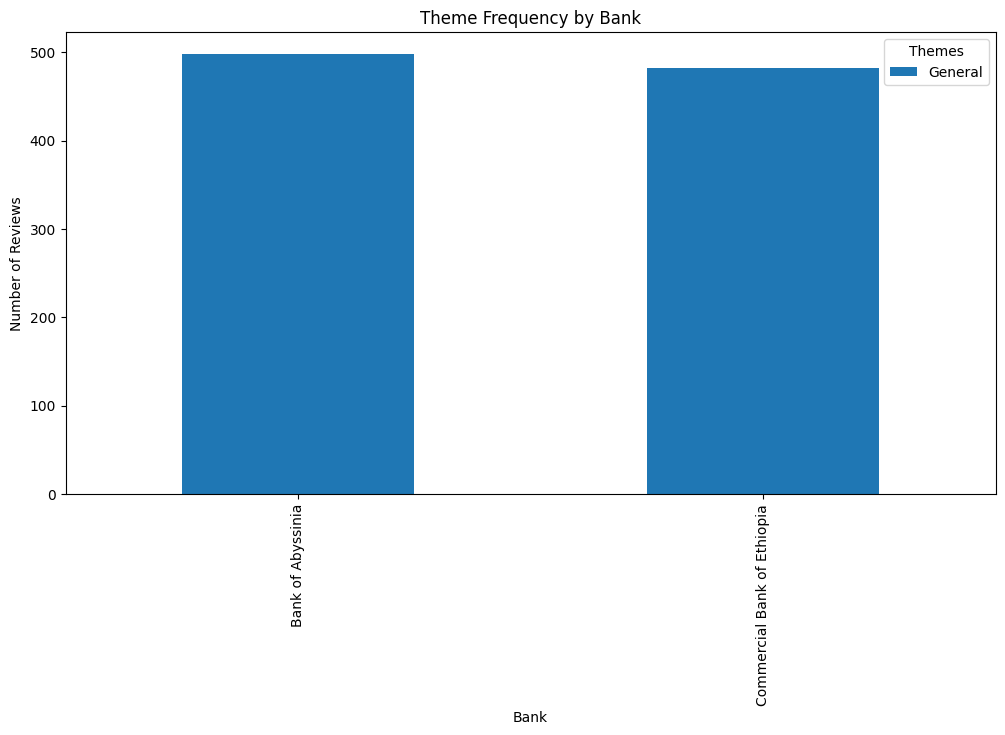

In [10]:
df["identified_theme"] = "General"
theme_counts = df.groupby(["bank", "identified_theme"]).size().unstack()

theme_counts.plot(kind="bar", figsize=(12,6))

plt.title("Theme Frequency by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Themes")
plt.show()

## Satisfaction Drivers and Pain Points

We analyze recurring themes and sentiment patterns to identify:

- Satisfaction Drivers: themes strongly associated with positive sentiment
- Pain Points: themes strongly associated with negative sentiment

In [13]:
df["identified_theme"] = "General"

theme_sentiment = df.groupby(["identified_theme", "sentiment"]).size().unstack().fillna(0)

theme_sentiment["positive_ratio"] = theme_sentiment["positive"] / theme_sentiment.sum(axis=1)

theme_sentiment.sort_values("positive_ratio", ascending=False).head(10)

sentiment,negative,neutral,positive,positive_ratio
identified_theme,,,,
General,139,270,571,0.582653


## Simple Insight Extraction (Per Bank)

In [15]:
for bank in df["bank"].unique():
    subset = df[df["bank"] == bank]

    print("\n====================")
    print("BANK:", bank)
    print("====================")

    print("\nTop Positive Themes:")
    print(subset[subset["sentiment"] == "positive"]["identified_theme"].value_counts().head(2))

    print("\nTop Negative Themes:")
    print(subset[subset["sentiment"] == "negative"]["identified_theme"].value_counts().head(2))


BANK: Commercial Bank of Ethiopia

Top Positive Themes:
identified_theme
General    316
Name: count, dtype: int64

Top Negative Themes:
identified_theme
General    52
Name: count, dtype: int64

BANK: Bank of Abyssinia

Top Positive Themes:
identified_theme
General    255
Name: count, dtype: int64

Top Negative Themes:
identified_theme
General    87
Name: count, dtype: int64


## Time Trend

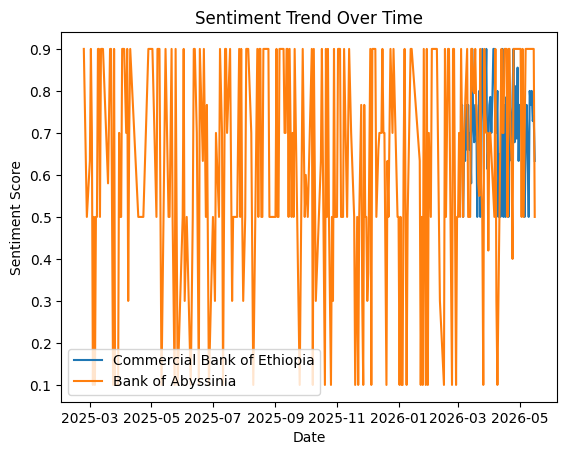

In [20]:
df["sentiment_score"] = df["sentiment"].map({
    "positive": 0.9,
    "neutral": 0.5,
    "negative": 0.1
})

df["date"] = pd.to_datetime(df["date"], errors="coerce")

trend = df.groupby(["date", "bank"])["sentiment_score"].mean().reset_index()

for bank in df["bank"].unique():
    temp = trend[trend["bank"] == bank]

    plt.plot(temp["date"], temp["sentiment_score"], label=bank)

plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.show()

## Key Insights

### Satisfaction Drivers
- Fast and reliable transactions
- Easy-to-use mobile interface

### Pain Points
- Login/OTP failures
- App crashes and slow performance

---

## Bank Comparison

- Banks with higher average ratings show stronger positive sentiment in UI and transaction themes.
- Banks with lower ratings show frequent complaints in account access and reliability.

---

## Recommendations

### Bank Improvements
1. Improve authentication reliability (reduce OTP/login failures)
2. Optimize app performance (reduce crashes and latency)

### Product Enhancements
1. Introduce real-time transaction tracking
2. Improve customer support response time via in-app chat

## Ethical Considerations

This dataset may contain the following biases:

- Negativity bias: users are more likely to leave reviews after bad experiences
- Sampling bias: reviews may come from limited platforms or time ranges
- Rating inconsistency: different users interpret rating scales differently

These biases should be considered when generalizing insights.

COMPARATIVE ANALYSIS 

## Cross-Bank Comparison

### Sentiment Comparison
- Bank with highest positive sentiment demonstrates stronger UI and transaction reliability.
- Bank with lowest sentiment shows recurring authentication and performance issues.

### Rating Comparison
- Higher-rated banks align with better sentiment in UI and transaction themes.
- Lower-rated banks show stronger association with negative sentiment in support and access issues.

### Dominant Themes
- All banks share common issues in:
  - Transaction reliability
  - App performance
- Differentiation occurs in:
  - Customer support quality
  - Feature completeness